<a href="https://colab.research.google.com/github/joonookwak/Quality-Control-Chart-Analysis/blob/main/MR%2CIndividual%2Cp%2Cc%2Cu_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics

# Variable Control Charts

### Load dataset

In [ ]:
data = pd.read_csv('1_Variable_Control_Chart_Data.csv')

In [ ]:
data

,x1,x2,x3,x4
0,6,9,10,15
1,10,4,6,11
2,7,8,10,5
3,8,9,6,13
4,9,10,7,13
5,12,11,10,10
6,16,10,8,9
7,7,5,10,4
8,9,7,8,12
9,15,16,10,13


### Split phase 1, 2 dataset

In [ ]:
phase_1 = data[:15]
phase_2 = data[15:]

In [ ]:
phase_1

,x1,x2,x3,x4
0,6,9,10,15
1,10,4,6,11
2,7,8,10,5
3,8,9,6,13
4,9,10,7,13
5,12,11,10,10
6,16,10,8,9
7,7,5,10,4
8,9,7,8,12
9,15,16,10,13


In [ ]:
phase_2

,x1,x2,x3,x4
15,15,10,11,14
16,9,8,12,10
17,15,7,10,11
18,8,6,9,12
19,13,14,11,15


In [ ]:
x_bar = [] # average
r = [] # range of the values
s = [] # standard deviation

for group in np.array(phase_1):
    x_bar.append(group.mean())
    r.append(group.max() - group.min())
    s.append(np.std(group))

In [ ]:
x_bar



[10.0,
 7.75,
 7.5,
 9.0,
 9.75,
 10.75,
 10.75,
 6.5,
 9.0,
 13.5,
 12.5,
 20.5,
 13.25,
 21.75,
 11.0]

# Xbar Chart

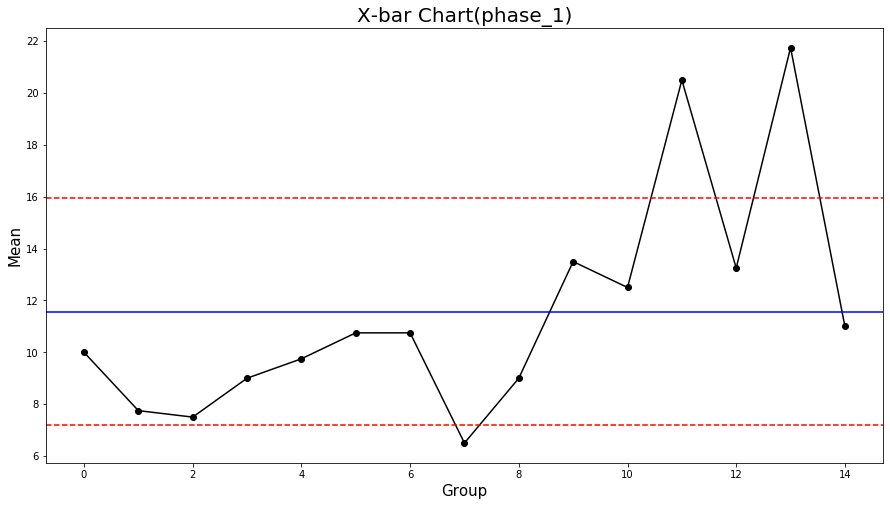

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(x_bar, linestyle='-', marker='o', color='black')
plt.axhline((statistics.mean(x_bar)+0.729*statistics.mean(r)), color='red', linestyle='--')
plt.axhline((statistics.mean(x_bar)-0.729*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(x_bar)), color='blue')
plt.title('X-bar Chart(phase_1)', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Mean', fontsize=15)
plt.show()

### check all points within out of control limits

In [ ]:
out_list = []
i = 0
control = True
for group in x_bar:
    if group > statistics.mean(x_bar)+0.729*statistics.mean(r) or group < statistics.mean(x_bar)-0.729*statistics.mean(r):
        print('Out of control limits -> Group number {}'.format(i))
        out_list.append(i)
        control = False
    i += 1
if control == True:
    print('All groups are within control limits.')

Out of control limits -> Group number 7
Out of control limits -> Group number 11
Out of control limits -> Group number 13


In [ ]:
out_list

[7, 11, 13]

In [ ]:
new_phase_1 = (phase_1.drop(out_list)).reset_index(drop = True)

In [ ]:
new_phase_1

,x1,x2,x3,x4
0,6,9,10,15
1,10,4,6,11
2,7,8,10,5
3,8,9,6,13
4,9,10,7,13
5,12,11,10,10
6,16,10,8,9
7,9,7,8,12
8,15,16,10,13
9,8,12,14,16


# R Chart

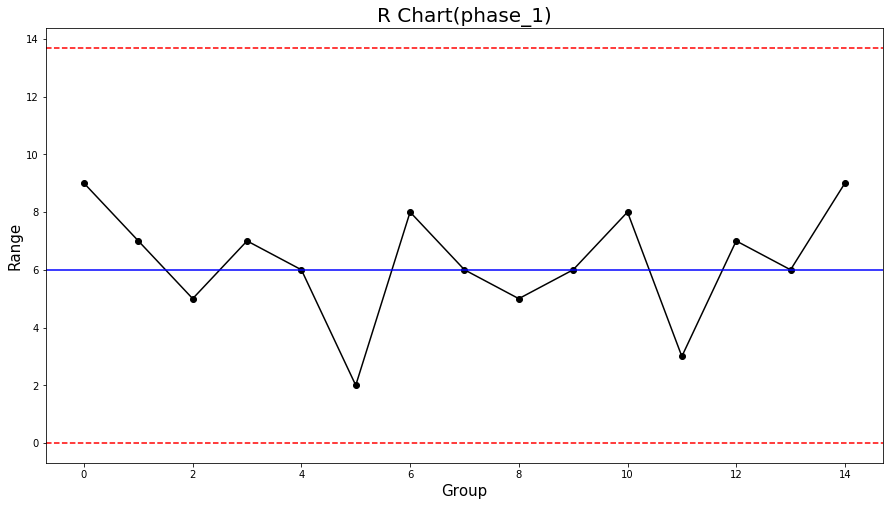

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(r, linestyle='-', marker='o', color='black')
plt.axhline((2.282*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((0*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(r)), color='blue')
# plt.ylim(bottom=0)
plt.title('R Chart(phase_1)', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Range', fontsize=15)
plt.show()

### check all points within out of control limits

In [ ]:
i = 0
control = True
for group in r:
    if group > 2.282*statistics.mean(r):
        print('Out of control limits -> Group number {}'.format(i))
        control = False
    i += 1
if control == True:
    print('All groups are within control limits.')

All groups are within control limits.


# S chart

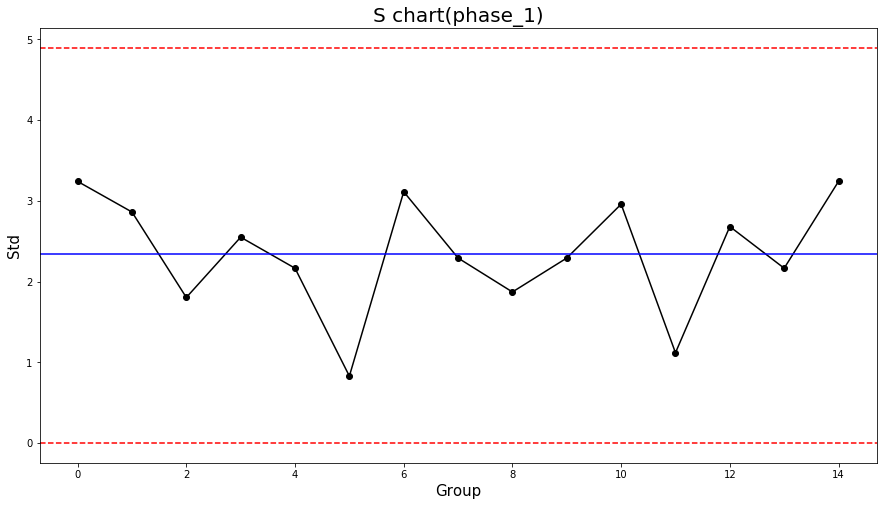

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(s, linestyle='-', marker='o', color='black')
plt.axhline((2.088*statistics.mean(s)), color='red', linestyle='dashed')
plt.axhline((0*statistics.mean(s)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(s)), color='blue')
plt.title('S chart(phase_1)', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Std', fontsize=15)
plt.show()

### check all points within out of control limits

In [ ]:
i = 0
control = True
for group in s:
    if group > 2.088*statistics.mean(s) or group < 0*statistics.mean(s):
        print('Out of control limits -> Group number {}'.format(i))
        control = False
    i += 1
if control == True:
    print('All groups are within control limits.')

All groups are within control limits.


# Individual chart


In [ ]:
data

,x1,x2,x3,x4
0,6,9,10,15
1,10,4,6,11
2,7,8,10,5
3,8,9,6,13
4,9,10,7,13
5,12,11,10,10
6,16,10,8,9
7,7,5,10,4
8,9,7,8,12
9,15,16,10,13


In [ ]:
x1 = phase_1['x1']

In [ ]:
x1

0      6
1     10
2      7
3      8
4      9
5     12
6     16
7      7
8      9
9     15
10     8
11    20
12    16
13    22
14    11
Name: x1, dtype: int64

In [ ]:
# add a np.nan in empty list
MR = [np.nan]

# setting moving ranges
i = 1
for dat in range(1, len(x1)):
    MR.append(abs(x1[i] - x1[i-1]))
    i += 1

In [ ]:
# Convert list to pd Series
MR = pd.Series(MR)

In [ ]:
MR

0      NaN
1      4.0
2      3.0
3      1.0
4      1.0
5      3.0
6      4.0
7      9.0
8      2.0
9      6.0
10     7.0
11    12.0
12     4.0
13     6.0
14    11.0
dtype: float64

In [ ]:
# Concatenate
data = pd.concat([x1,MR], axis=1)
data.columns = ['x1', 'mR']

In [ ]:
data['mR']

0      NaN
1      4.0
2      3.0
3      1.0
4      1.0
5      3.0
6      4.0
7      9.0
8      2.0
9      6.0
10     7.0
11    12.0
12     4.0
13     6.0
14    11.0
Name: mR, dtype: float64

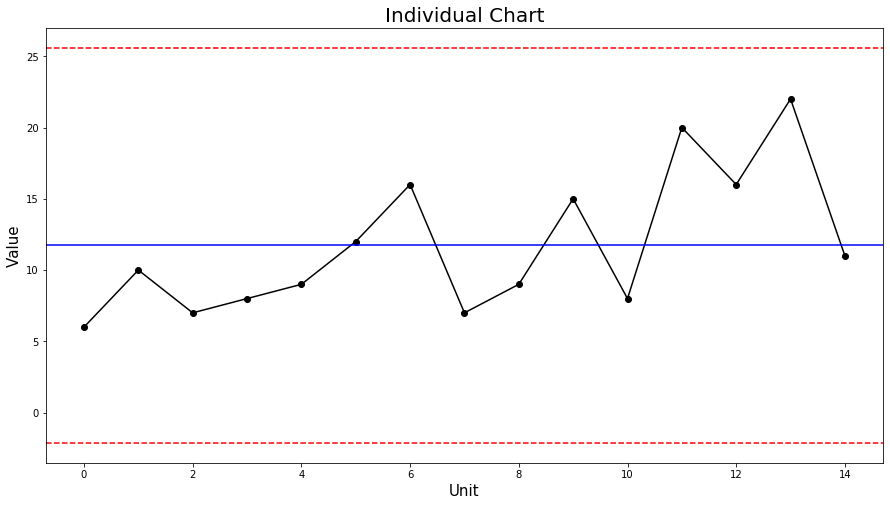

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(data['x1'], linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(data['x1']), color='blue')
plt.axhline(statistics.mean(data['x1'])+3*statistics.mean(data['mR'][1:len(data['mR'])])/1.128, color = 'red', linestyle = 'dashed')
plt.axhline(statistics.mean(data['x1'])-3*statistics.mean(data['mR'][1:len(data['mR'])])/1.128, color = 'red', linestyle = 'dashed')
plt.title('Individual Chart', fontsize=20)
plt.xlabel('Unit', fontsize=15)
plt.ylabel('Value', fontsize=15)
plt.show()

# MR chart

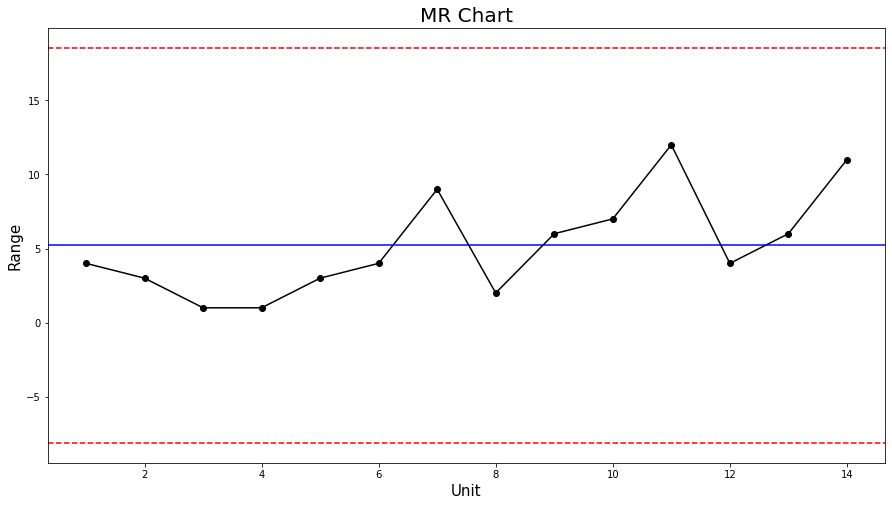

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(data['mR'], linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(data['mR'][1:len(data['mR'])]), color='blue')
plt.axhline(statistics.mean(data['mR'][1:len(data['mR'])])+3*statistics.mean(data['mR'][1:len(data['mR'])])*0.853, color='red', linestyle ='dashed')
plt.axhline(statistics.mean(data['mR'][1:len(data['mR'])])-3*statistics.mean(data['mR'][1:len(data['mR'])])*0.853, color='red', linestyle ='dashed')
plt.title('MR Chart', fontsize=20)
plt.xlabel('Unit', fontsize=15)
plt.ylabel('Range', fontsize=15)
plt.show()

# Phase 1 -> Phase 2

In [ ]:
x_bar_2 = [] # average
r_2 = [] # range of the values
s_2 = [] # standard deviation

for group in np.array(phase_2):
    # print(group)
    x_bar_2.append(group.mean())
    r_2.append(group.max() - group.min())
    s_2.append(np.std(group))

# Xbar Chart(phase 2)

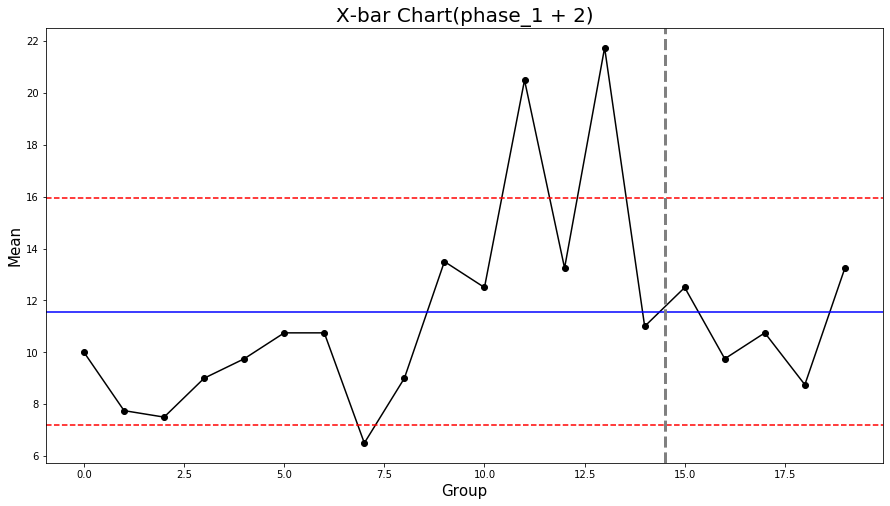

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot((x_bar + x_bar_2), linestyle='-', marker='o', color='black')
plt.axhline((statistics.mean(x_bar)+0.729*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(x_bar)-0.729*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(x_bar)), color='blue')

plt.axvline(14.5, color='grey', linestyle='--', linewidth=3)

plt.title('X-bar Chart(phase_1 + 2)', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Mean', fontsize=15)
plt.show()

# R chart(phase 2)

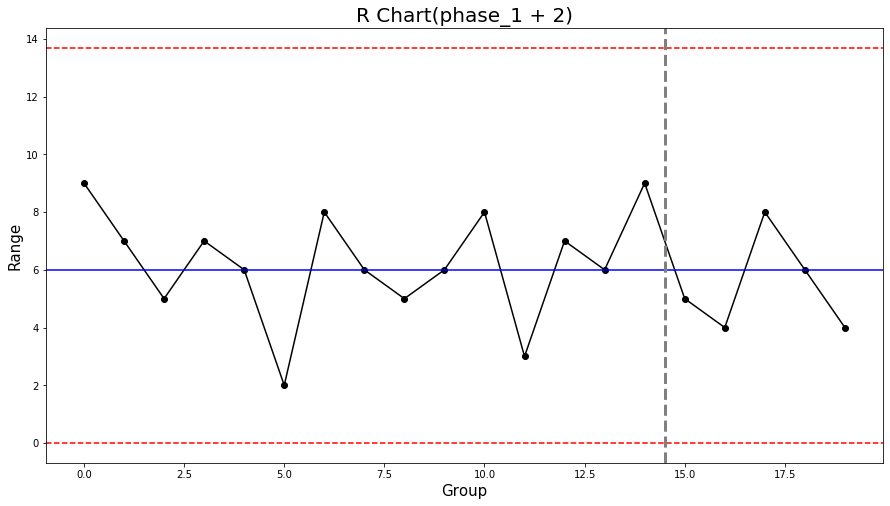

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot((r+r_2), linestyle='-', marker='o', color='black')
plt.axhline((2.282*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((0*statistics.mean(r)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(r)), color='blue')
plt.axvline(14.5, color='grey', linestyle='--', linewidth=3)
plt.title('R Chart(phase_1 + 2)', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Range', fontsize=15)
plt.show()

# S chart(phase 2)

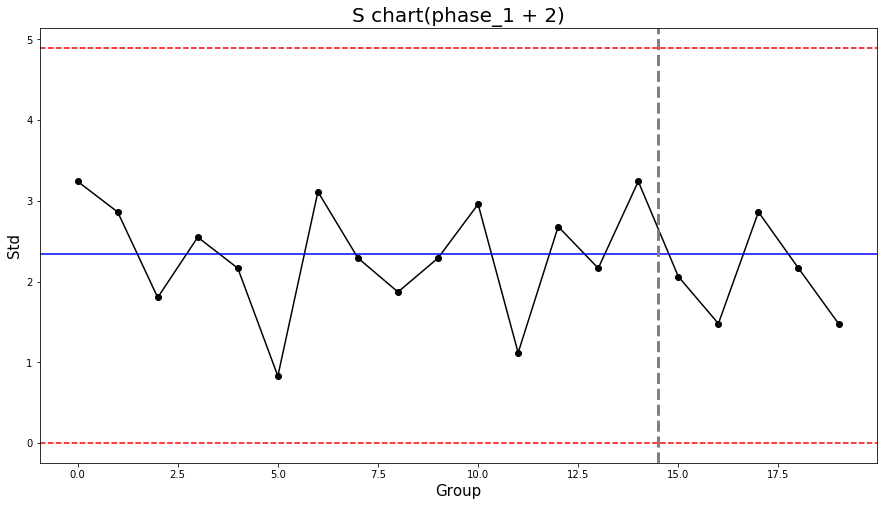

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot((s + s_2), linestyle='-', marker='o', color='black')
plt.axhline((2.088*statistics.mean(s)), color='red', linestyle='dashed')
plt.axhline((0*statistics.mean(s)), color='red', linestyle='dashed')
plt.axhline((statistics.mean(s)), color='blue')
plt.axvline(14.5, color='grey', linestyle='--', linewidth=3)
plt.title('S chart(phase_1 + 2)', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Std', fontsize=15)
plt.show()

# Individual chart(phase 2)

In [ ]:
x1_2 = phase_2['x1']

In [ ]:
x1_2 = x1_2.reset_index(drop = True)

In [ ]:
x1_2

0    15
1     9
2    15
3     8
4    13
Name: x1, dtype: int64

In [ ]:
# add a np.nan in empty list
MR_2 = [np.nan]

# setting moving ranges
i = 1
for dat in range(1, len(x1_2)):
    MR_2.append(abs(x1_2[i] - x1_2[i-1]))
    i += 1

In [ ]:
MR_2 = pd.Series(MR_2)
# Concatenate
data_2 = pd.concat([x1_2, MR_2], axis=1)
data_2.columns = ['x1', 'mR']

In [ ]:
data['x1']

0      6
1     10
2      7
3      8
4      9
5     12
6     16
7      7
8      9
9     15
10     8
11    20
12    16
13    22
14    11
Name: x1, dtype: int64

In [ ]:
data_2['x1']

0    15
1     9
2    15
3     8
4    13
Name: x1, dtype: int64

In [ ]:
data_1_2 = pd.concat((data ,data_2), axis = 0).reset_index(drop = True)

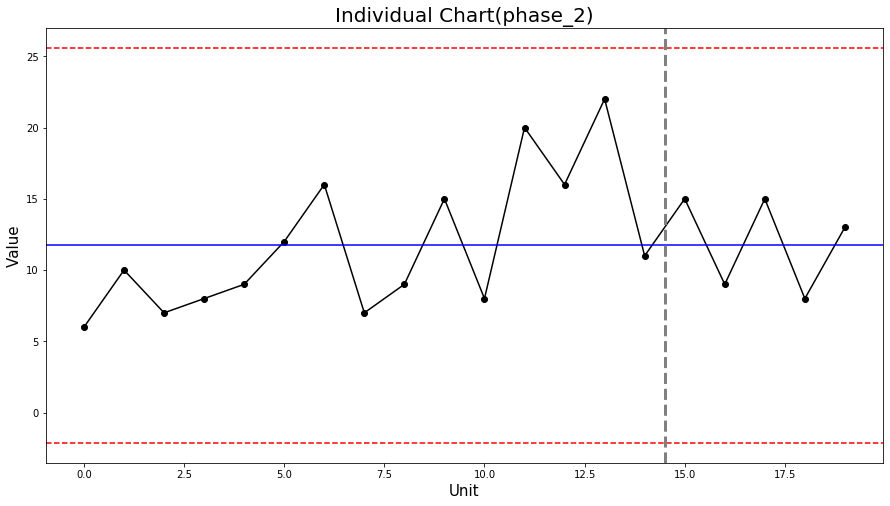

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(data_1_2['x1'], linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(data['x1']), color='blue')
plt.axhline(statistics.mean(data['x1'])+3*statistics.mean(data['mR'][1:len(data['mR'])])/1.128, color = 'red', linestyle = 'dashed')
plt.axhline(statistics.mean(data['x1'])-3*statistics.mean(data['mR'][1:len(data['mR'])])/1.128, color = 'red', linestyle = 'dashed')
plt.title('Individual Chart(phase_2)', fontsize=20)
plt.axvline(14.5, color='grey', linestyle='--', linewidth=3)
plt.xlabel('Unit', fontsize=15)
plt.ylabel('Value', fontsize=15)
plt.show()

# MR chart(phase 2)

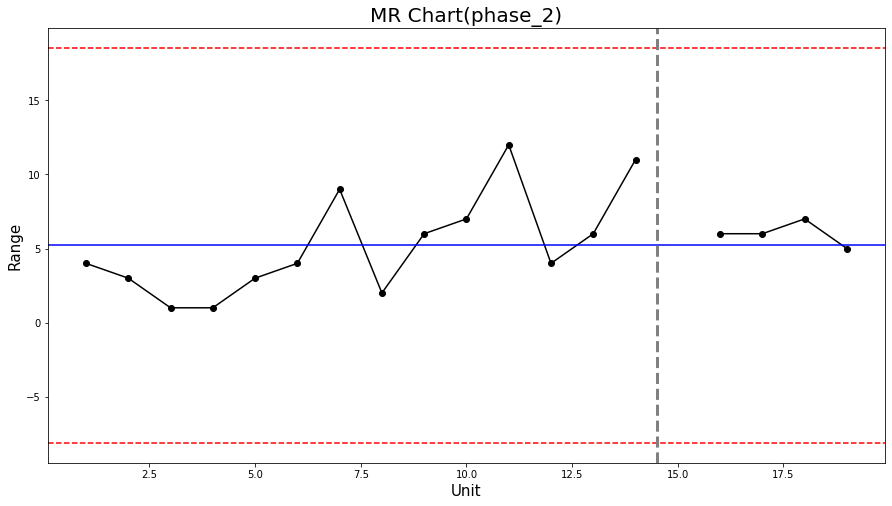

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(data_1_2['mR'], linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(data['mR'][1:len(data['mR'])]), color='blue')
plt.axhline(statistics.mean(data['mR'][1:len(data['mR'])])+3*statistics.mean(data['mR'][1:len(data['mR'])])*0.853, color='red', linestyle ='dashed')
plt.axhline(statistics.mean(data['mR'][1:len(data['mR'])])-3*statistics.mean(data['mR'][1:len(data['mR'])])*0.853, color='red', linestyle ='dashed')
plt.title('MR Chart(phase_2)', fontsize=20)
plt.axvline(14.5, color='grey', linestyle='--', linewidth=3)
plt.xlabel('Unit', fontsize=15)
plt.ylabel('Range', fontsize=15)
plt.show()

# Attributes Control Charts

# P chart

### Load dataset

In [ ]:
data = pd.read_csv('2_Attribute_Control_Chart_Data.csv')

In [ ]:
data

,Number of Nonconforming Assemblies
0,7
1,4
2,1
3,3
4,6
5,8
6,10
7,5
8,2
9,7


### define a size

In [ ]:
size = 100
data['Number of Nonconforming Assemblies']/size

0     0.07
1     0.04
2     0.01
3     0.03
4     0.06
5     0.08
6     0.10
7     0.05
8     0.02
9     0.07
10    0.06
11    0.15
12    0.00
13    0.09
14    0.05
15    0.01
16    0.04
17    0.05
18    0.07
19    0.12
Name: Number of Nonconforming Assemblies, dtype: float64

In [ ]:
p_data

0     0.077778
1     0.040816
2     0.010753
3     0.032258
4     0.064516
5     0.082474
6     0.094340
7     0.055556
8     0.020000
9     0.070707
10    0.055046
11    0.148515
12    0.000000
13    0.096774
14    0.052083
15    0.010526
16    0.037736
17    0.051020
18    0.072917
19    0.131868
Name: Number of Nonconforming Assemblies, dtype: float64

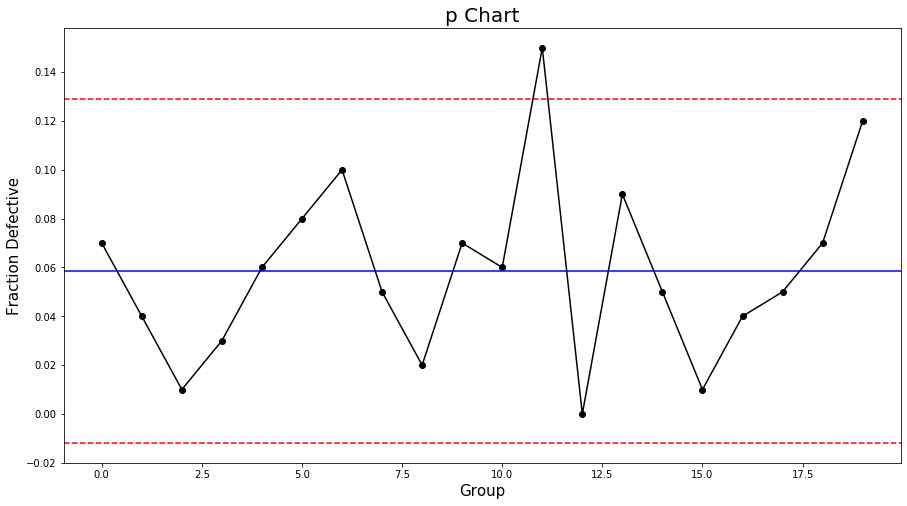

In [ ]:
p_data = data['Number of Nonconforming Assemblies']/size

# Plot p-chart
fig = plt.figure(figsize=(15,8))
plt.plot(p_data, linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(p_data)+3*(np.sqrt((statistics.mean(p_data)*(1-statistics.mean(p_data)))/(size))), color='red', linestyle ='dashed')
plt.axhline(statistics.mean(p_data)-3*(np.sqrt((statistics.mean(p_data)*(1-statistics.mean(p_data)))/(size))), color='red', linestyle ='dashed')
plt.axhline(statistics.mean(p_data), color='blue')

plt.title('p Chart', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Fraction Defective', fontsize=15)
plt.show()


### check all points within out of control limits

In [ ]:
UCL = statistics.mean(p_data)+3*(np.sqrt((statistics.mean(p_data)*(1-statistics.mean(p_data)))/(size)))
LCL = statistics.mean(p_data)-3*(np.sqrt((statistics.mean(p_data)*(1-statistics.mean(p_data)))/(size)))
out_list = []
i = 0
control = True
for group in p_data:
    if group > UCL or group < LCL:
        print('Out of control limits -> Group number {}'.format(i))
        out_list.append(i)
        control = False
    i += 1
if control == True:
    print('All groups are within control limits.')

Out of control limits -> Group number 11


In [ ]:
out_list

[11]

In [ ]:
p_data

0     0.07
1     0.04
2     0.01
3     0.03
4     0.06
5     0.08
6     0.10
7     0.05
8     0.02
9     0.07
10    0.06
11    0.15
12    0.00
13    0.09
14    0.05
15    0.01
16    0.04
17    0.05
18    0.07
19    0.12
Name: Number of Nonconforming Assemblies, dtype: float64

### a data of index 11 is eliminated

In [ ]:
new_p_data = p_data.drop(out_list).reset_index(drop = True)

In [ ]:
new_p_data

0     0.07
1     0.04
2     0.01
3     0.03
4     0.06
5     0.08
6     0.10
7     0.05
8     0.02
9     0.07
10    0.06
11    0.00
12    0.09
13    0.05
14    0.01
15    0.04
16    0.05
17    0.07
18    0.12
Name: Number of Nonconforming Assemblies, dtype: float64

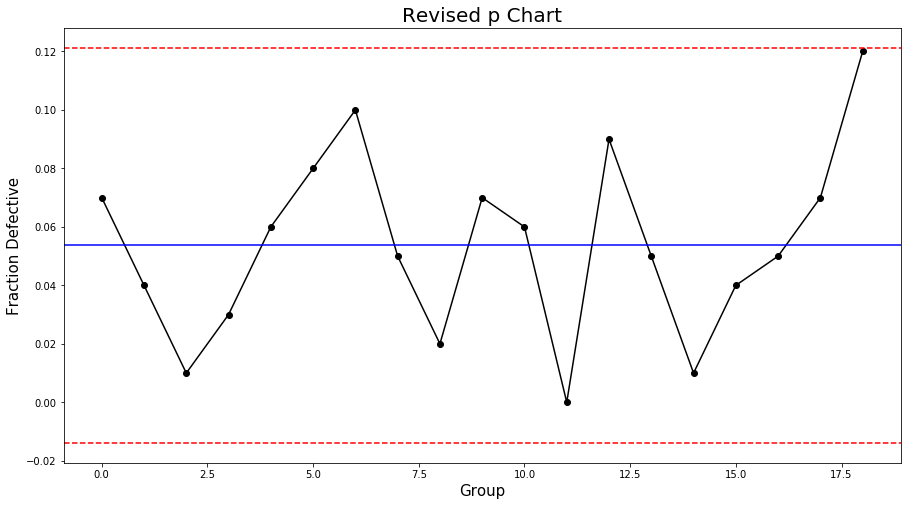

In [ ]:
# UCL, LCL are depending on size

fig = plt.figure(figsize=(15,8))
plt.plot(new_p_data, linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(new_p_data)+3*(np.sqrt((statistics.mean(new_p_data)*(1-statistics.mean(new_p_data)))/(size))),
            color='red', linestyle ='dashed')
plt.axhline(statistics.mean(new_p_data)-3*(np.sqrt((statistics.mean(new_p_data)*(1-statistics.mean(new_p_data)))/(size))),
            color='red', linestyle ='dashed')
plt.axhline(statistics.mean(new_p_data), color='blue')

plt.title('Revised p Chart', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Fraction Defective', fontsize=15)
plt.show()


### check all points within out of control limits

In [ ]:
UCL = statistics.mean(new_p_data)+3*(np.sqrt((statistics.mean(new_p_data)*(1-statistics.mean(new_p_data)))/(size)))
LCL = statistics.mean(new_p_data)-3*(np.sqrt((statistics.mean(new_p_data)*(1-statistics.mean(new_p_data)))/(size)))
out_list = []
i = 0
control = True
for group in new_p_data:
    if group > UCL or group < LCL:
        print('Out of control limits -> Group number {}'.format(i))
        out_list.append(i)
        control = False
    i += 1
if control == True:
    print('All groups are within control limits.')

All groups are within control limits.


# c chart

In [ ]:
data['Number of Nonconforming Assemblies']

0      7
1      4
2      1
3      3
4      6
5      8
6     10
7      5
8      2
9      7
10     6
11    15
12     0
13     9
14     5
15     1
16     4
17     5
18     7
19    12
Name: Number of Nonconforming Assemblies, dtype: int64

In [ ]:
c_data = data['Number of Nonconforming Assemblies']

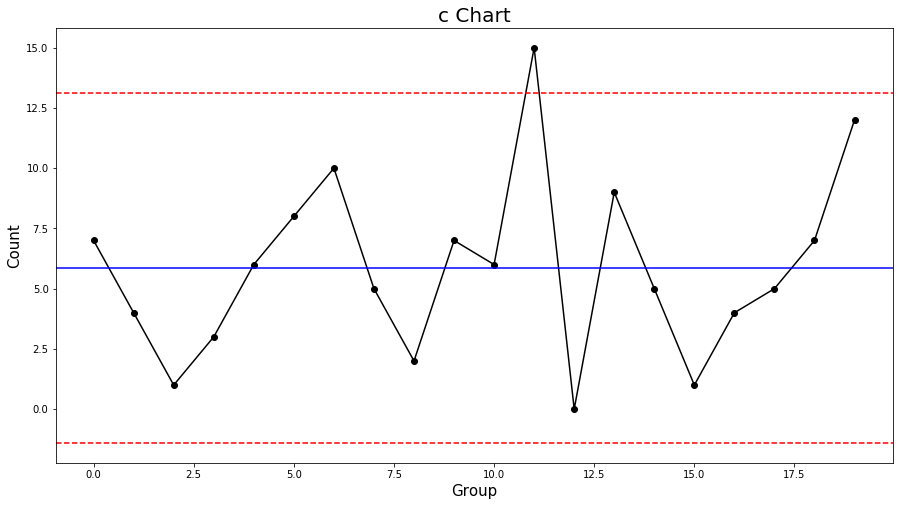

In [ ]:
fig = plt.figure(figsize=(15,8))
plt.plot(c_data, linestyle='-', marker='o', color='black')
plt.axhline(statistics.mean(c_data)+3*np.sqrt(statistics.mean(c_data)),
            color='red', linestyle='dashed')
plt.axhline(statistics.mean(c_data)-3*np.sqrt(statistics.mean(c_data)),
            color='red', linestyle='dashed')
plt.axhline(statistics.mean(c_data), color='blue')

plt.title('c Chart', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()



### check all points within out of control limits


In [ ]:
UCL = statistics.mean(c_data)+3*np.sqrt(statistics.mean(c_data))
LCL = statistics.mean(c_data)-3*np.sqrt(statistics.mean(c_data))
out_list = []
i = 0
control = True
for group in c_data:
    if group > UCL or group < LCL:
        print('Out of control limits -> Group number {}'.format(i))
        out_list.append(i)
        control = False
    i += 1
if control == True:
    print('All groups are within control limits.')

Out of control limits -> Group number 11


# U chart

In [ ]:
np.random.seed(2020)

# u chart has random size
size = np.random.randint(90,110,20).tolist()

In [ ]:
u_data = pd.DataFrame()

In [ ]:
u_data['Nonconforming'] = data['Number of Nonconforming Assemblies']

In [ ]:
u_data['size'] = pd.DataFrame(size)

In [ ]:
u_data

,Nonconforming,size
0,7,90
1,4,98
2,1,93
3,3,93
4,6,93
5,8,97
6,10,106
7,5,90
8,2,100
9,7,99


In [ ]:
u_data['u'] = u_data['Nonconforming']/u_data['size']

In [ ]:
u_data

,Nonconforming,size,u
0,7,90,0.077778
1,4,98,0.040816
2,1,93,0.010753
3,3,93,0.032258
4,6,93,0.064516
5,8,97,0.082474
6,10,106,0.094340
7,5,90,0.055556
8,2,100,0.020000
9,7,99,0.070707


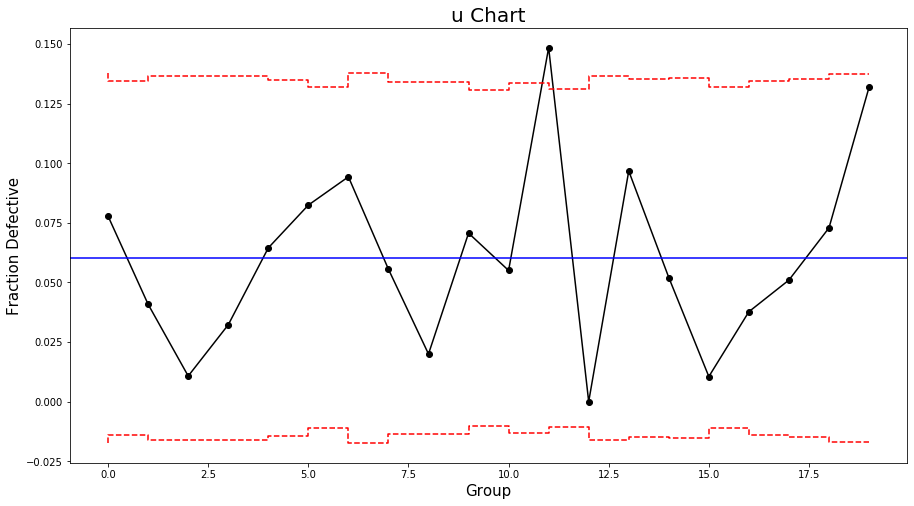

In [ ]:
# UCL, LCL are depending on size

fig = plt.figure(figsize=(15,8))
plt.plot(u_data['u'], linestyle='-', marker='o', color='black')
plt.step(x=range(0, len(u_data['u'])),
         y=u_data['u'].mean()+3*np.sqrt(u_data['u'].mean()/u_data['size']),
         color='red', linestyle='dashed')
plt.step(x=range(0, len(u_data['u'])),
         y=u_data['u'].mean()-3*np.sqrt(u_data['u'].mean()/u_data['size']),
         color='red', linestyle='dashed')
plt.axhline(statistics.mean(u_data['u']), color='blue')

plt.title('u Chart', fontsize=20)
plt.xlabel('Group', fontsize=15)
plt.ylabel('Fraction Defective', fontsize=15)
plt.show()

# Personal exercise

### make a phase-2 dataset and let it be used in P, C, U chart as we learned

### Reference

https://towardsdatascience.com/quality-control-charts-guide-for-python-9bb1c859c051